In [1]:
2+3

5

In [10]:
import os
from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_tavily import TavilySearch
from langchain.chat_models import init_chat_model



In [4]:
load_dotenv()

True

In [5]:
tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph ? · Hugging Face',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your

In [20]:
## custom function

def multiply(a:int,b:int)->int:
    """ Multiply a and b
    Args:
        a (int) : frist number
        b (int) : second number
    return:
        int : Output int

    """
    return a*b

In [26]:
tools = [tool,multiply]

In [27]:
llm = init_chat_model("groq:llama-3.1-8b-instant")

In [28]:
llm_with_tool = llm.bind_tools(tools)

In [13]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024892B88C20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002489293AEA0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

In [16]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

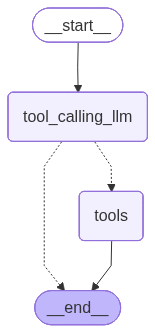

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image,display

# Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to a tool
    # if the latest message (result) from assistant is not  a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

# complile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [18]:
graph.invoke({"messages":["what is recent ai news"]})

{'messages': [HumanMessage(content='what is recent ai news', additional_kwargs={}, response_metadata={}, id='69cd6d9f-3693-4c82-bdbc-10d3eab93d74'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'eeqakaz50', 'function': {'arguments': '{"query":"recent AI news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1800, 'total_tokens': 1824, 'completion_time': 0.078630764, 'completion_tokens_details': None, 'prompt_time': 0.172570878, 'prompt_tokens_details': None, 'queue_time': 0.055752561, 'total_time': 0.251201642}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4a27-936a-78c0-ab2a-ca7051fd72bf-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'topic': 'news'}, 'id': 'eeqakaz50', 'type': 'tool_call'}]

In [69]:
responce = graph.invoke({"messages":(["what is multiplication of 5 and 3"])})

In [31]:
responce['messages'][-1].content

'15'

In [48]:
import os
from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_tavily import TavilySearch
from langchain.chat_models import init_chat_model

In [49]:
load_dotenv()

True

In [50]:
# 1st tool 
tool = TavilySearch(max_results=2)
responce_tavily_tool = tool.invoke("What is langgraph")
responce_tavily_tool

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for build

In [51]:
# 2nd tool
def multiply(a:int, b:int)-> int:
    """Multiply a and b """
    return a*b

In [52]:
# List of tools
tools = [tool,multiply]

In [53]:
# Initilize llm
llm = init_chat_model("groq:llama-3.1-8b-instant")

In [54]:
# Build tool with llm
llm_with_tool = llm.bind_tools(tools)

In [55]:
# define graph state


class State(TypedDict):
    messages : Annotated[list,add_messages]

In [62]:
# create a chatbot node

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

In [63]:
# build a langgraph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

In [64]:
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)

In [65]:
graph = builder.compile()

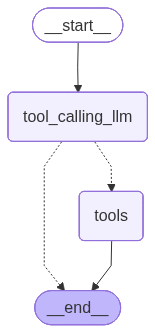

In [66]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [67]:
graph.invoke({"messages": ["what is recent ai news"]})

{'messages': [HumanMessage(content='what is recent ai news', additional_kwargs={}, response_metadata={}, id='6cfbbfad-c95e-4202-b11c-bf995997dd61'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '499dr23wh', 'function': {'arguments': '{"query":"recent AI news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'gz30en8rn', 'function': {'arguments': '{"query":"AI recent news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'gaeggm2ca', 'function': {'arguments': '{"query":"latest AI news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 1740, 'total_tokens': 1810, 'completion_time': 0.101630775, 'completion_tokens_details': None, 'prompt_time': 0.155367105, 'prompt_tokens_details': None, 'queue_time': 0.093665901, 'total_time': 0.25699788}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier':

In [68]:
responce = graph.invoke({"messages": ["what is multiplication of 5 and 3"]})
responce['messages'][-1].content

'15'

In [ ]:
responce = graph.invoke({
    "messages":["what is recent ai news and 5 multiply by 10"]
})


for m in responce['messages']:
    m.pretty_print()


================================ Human Message =================================

what is recent ai news and 5 multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ag7gdjqfs)
 Call ID: ag7gdjqfs
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (g95b0z620)
 Call ID: g95b0z620
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.insurancejournal.com/news/international/2026/05/21/870833.htm", "title": "Viewpoint: Insurers Cautiously Navigate the Next Step in AI Adoption - Insurance Journal", "score": 0.58664185, "published_date": "Thu, 21 May 2026 05:03:37 GMT", "content": "As more and more companies embed AI into select functions, only a portion indicate that they have used AI to change how an